In [ ]:
# Enable the autoreload extension
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np

np.random.seed(1999)

In [ ]:
from datetime import datetime, timedelta

import numpy as np
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
)

SIM_PARAMS = {
    "start_time": datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval": timedelta(seconds=10),
    "num_steps": 180,
}

SHIP_PARAMS = {
    # "start_vector": np.array([0, 1.82, 0, 1.82, -10.0, 0]), # 5 knots = 2.57 m/s
    "start_vector": np.array([0, 0, 0, 0, -10.0, 0]), # stationary ship
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    # "transition_model": CombinedLinearGaussianTransitionModel(
    #     [ConstantVelocity(0.0001), ConstantVelocity(0.0001), ConstantVelocity(0)]
    # ),
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

ARRAY_PARAMS = {
    "num_sensors": 1000,
    "tow_cable_length": 1800.0,
    "sensor_spacing": 1.0,
    "array_depth": -1000.0,
}


# Generate platform path

In [ ]:
from stonesoup.types.groundtruth import GroundTruthState

from nereus.stonesoup.platform import TowedArrayPlatform

initial_state = GroundTruthState(
    SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"]
)

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_model=SHIP_PARAMS["transition_model"],
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

In [ ]:
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from IPython.display import HTML, display
# from matplotlib.animation import FuncAnimation

# plt.rcParams['animation.embed_limit'] = 100  # Set to 100 MB (default is 20 MB)

# sns.set_theme(style="whitegrid")
# fig = plt.figure(figsize=(6, 6))
# ax = fig.add_subplot(projection='3d')

# # --------------------------------------------------
# # Extract paths
# host_positions = platform.host_path
# sensor_paths = platform.sensor_paths

# # Get dimensions for animation
# num_time_steps = len(platform.states)
# num_sensors = len(platform.towed_sensors)
# # --------------------------------------------------

# # Set plot limits dynamically for all 3 axes
# all_x = np.concatenate([host_positions[:, 0]] + [path[:, 0] for path in sensor_paths])
# all_y = np.concatenate([host_positions[:, 1]] + [path[:, 1] for path in sensor_paths])
# all_z = np.concatenate([host_positions[:, 2]] + [path[:, 2] for path in sensor_paths])
# ax.set_xlim(all_x.min() - 100, all_x.max() + 100)
# ax.set_ylim(all_y.min() - 100, all_y.max() + 100)
# ax.set_zlim(all_z.min() - 20, all_z.max() + 20)

# ax.set_title("3D Towed Array Simulation")
# ax.set_xlabel("X Position (m)")
# ax.set_ylabel("Y Position (m)")
# ax.set_zlabel("Depth (m)")

# # Initialise artists for the animation in 3D
# (point_host,) = ax.plot([], [], [], "o", markersize=10, color="C0", label="Host Vehicle")
# (line_host,) = ax.plot([], [], [], "--", alpha=0.6, color="C0", label="Host Path")
# (line_array,) = ax.plot([], [], [], "o-", markersize=5, color="k", label="Towed Array")
# ax.legend()

# def update(frame):
#     """Update the animation for each frame."""
#     # Get the 3D position of all nodes at the current frame
#     all_nodes_x = [host_positions[frame, 0]] + [path[frame, 0] for path in sensor_paths]
#     all_nodes_y = [host_positions[frame, 1]] + [path[frame, 1] for path in sensor_paths]
#     all_nodes_z = [host_positions[frame, 2]] + [path[frame, 2] for path in sensor_paths]

#     point_host.set_data_3d([all_nodes_x[0]], [all_nodes_y[0]], [all_nodes_z[0]])

#     line_host.set_data(host_positions[: frame + 1, 0], host_positions[: frame + 1, 1])
#     line_host.set_3d_properties(host_positions[: frame + 1, 2])
#     line_array.set_data(all_nodes_x, all_nodes_y)
#     line_array.set_3d_properties(all_nodes_z)

#     return point_host, line_host, line_array

# ani = FuncAnimation(
#     fig, update, frames=SIM_PARAMS["num_steps"], blit=False, interval=100
# )

# plt.close()
# display(HTML(ani.to_jshtml()))

# Generate source path

In [ ]:
from stonesoup.types.groundtruth import GroundTruthPath, GroundTruthState

TARGET_PARAMS = {
    "start_vector": np.array([5000, -7.28, 40000, 7.28, -10.0, 0]), # 20 knots = 10.29 m/s
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0.001), ConstantVelocity(0.001), ConstantVelocity(0)]
    ),
    "amplitudes_upa": 10 ** (np.array([180.0, 165.0, 170.0]) / 20),
    "frequencies_hz": np.array([125.0, 190.0, 285.0]),
    "phases_rad": np.deg2rad([-112.0, -151.0, 86.0])
}

# Create initial state with acoustic metadata
target_states = [GroundTruthState(
    TARGET_PARAMS["start_vector"],
    timestamp=SIM_PARAMS["start_time"],
    metadata={
        'amplitudes_upa': TARGET_PARAMS["amplitudes_upa"],
        'frequencies_hz': TARGET_PARAMS["frequencies_hz"],
        'phases_rad': TARGET_PARAMS["phases_rad"]
    }
)]

# Generate trajectory using transition model
transition_model = TARGET_PARAMS["transition_model"]
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    time_interval = new_time - target_states[-1].timestamp

    # Apply transition model to get new state
    new_state_vector = transition_model.function(
        target_states[-1],
        noise=True,
        time_interval=time_interval
    )

    new_state = GroundTruthState(
        new_state_vector,
        timestamp=new_time,
        metadata={
            'amplitudes_upa': TARGET_PARAMS["amplitudes_upa"],
            'frequencies_hz': TARGET_PARAMS["frequencies_hz"],
            'phases_rad': TARGET_PARAMS["phases_rad"]
        }
    )
    target_states.append(new_state)

# Create ground truth path object
target_ground_truth = GroundTruthPath(target_states)


In [ ]:
from nereus.stonesoup.plotter import BearingsPlotter

# Calculate platform center position
platform_center_x = (ARRAY_PARAMS["num_sensors"] - 1) * ARRAY_PARAMS["sensor_spacing"] / 2.0
platform_center_y = 0.0  # Platform is at origin in Y
platform_center = np.array([platform_center_x, platform_center_y])

# Store ground truth bearings at each time step
ground_truth_bearings = []
ground_truth_positions = []
for target_state in target_ground_truth.states:
    # Extract target position (x, y) from state vector [x, vx, y, vy, z, vz]
    target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])

    # Calculate relative position from platform center to target
    relative_pos = target_pos - platform_center

    # Convert to bearing (angle from positive x-axis, measured counter-clockwise)
    bearing_rad = np.arctan2(relative_pos[1], relative_pos[0])

    ground_truth_bearings.append(bearing_rad)
    ground_truth_positions.append(target_pos.copy())

# Convert to numpy arrays for easier manipulation
ground_truth_bearings = np.array(ground_truth_bearings)
ground_truth_positions = np.array(ground_truth_positions)

# Create GroundTruthPath from the bearing measurements
bearing_truth_states = []
for i, bearing in enumerate(ground_truth_bearings):
    timestamp = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    # Create a state vector with just the bearing (no bearing rate for now)
    bearing_state = GroundTruthState(
        state_vector=np.array([bearing]),
        timestamp=timestamp
    )
    bearing_truth_states.append(bearing_state)

# Create the GroundTruthPath object
bearing_ground_truth = GroundTruthPath(bearing_truth_states)

timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"] \
        for i in range(SIM_PARAMS["num_steps"])
]

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide)

plotter.plot(
    [bearing_ground_truth],  # Pass as list of GroundTruthPath objects
    [],
    [],
    timesteps=timesteps,
    mapping=[0]
)
plotter.show()

In [ ]:
# import matplotlib.pyplot as plt
# from IPython.display import HTML, display
# from matplotlib.animation import FuncAnimation

# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(projection='3d')

# # --- Extract full 3D path data for all objects ---
# host_positions = platform.host_path
# sensor_paths = platform.sensor_paths

# target_positions = np.array(
#     [s.state_vector[[0, 2, 4]].flatten() for s in target_ground_truth.states]
# )

# # --- Set plot limits dynamically to include all objects ---
# all_x = np.concatenate([
#     host_positions[:, 0]] +
#     [path[:, 0] for path in sensor_paths] +
#     [target_positions[:, 0]]
# )
# all_y = np.concatenate([
#     host_positions[:, 1]] +
#     [path[:, 1] for path in sensor_paths] +
#     [target_positions[:, 1]]
# )
# all_z = np.concatenate([
#     host_positions[:, 2]] +
#     [path[:, 2] for path in sensor_paths] +
#     [target_positions[:, 2]]
# )
# ax.set_xlim(all_x.min() - 100, all_x.max() + 100)
# ax.set_ylim(all_y.min() - 100, all_y.max() + 100)
# ax.set_zlim(all_z.min() - 20, all_z.max() + 20)

# ax.set_title("3D Towed Array and Target Simulation")
# ax.set_xlabel("X Position (m)")
# ax.set_ylabel("Y Position (m)")
# ax.set_zlabel("Depth (m)")

# # --- Initialise artists for the animation ---
# (point_host,) = ax.plot([], [], [], "o", markersize=8, color="royalblue", label="Host Vehicle")
# (line_host,) = ax.plot([], [], [], "--", alpha=0.6, color="C0", label="Host Path")
# (line_array,) = ax.plot([], [], [], "o-", markersize=3, color="black", label="Towed Array")
# (point_target,) = ax.plot([], [], [], "o", markersize=8, color="red", label="Target")
# (line_target,) = ax.plot([], [], [], "--", alpha=0.6, color="red", label="Target Path")
# ax.legend()

# def update(frame):
#     """Update the animation for each frame."""
#     # Update host and array positions
#     all_nodes_x = [host_positions[frame, 0]] + [path[frame, 0] for path in sensor_paths]
#     all_nodes_y = [host_positions[frame, 1]] + [path[frame, 1] for path in sensor_paths]
#     all_nodes_z = [host_positions[frame, 2]] + [path[frame, 2] for path in sensor_paths]

#     point_host.set_data_3d([all_nodes_x[0]], [all_nodes_y[0]], [all_nodes_z[0]])
#     line_array.set_data_3d(all_nodes_x, all_nodes_y, all_nodes_z)
#     line_host.set_data(host_positions[:frame + 1, 0], host_positions[:frame + 1, 1])
#     line_host.set_3d_properties(host_positions[:frame + 1, 2])

#     # Update target position
#     point_target.set_data_3d(
#         [target_positions[frame, 0]],
#         [target_positions[frame, 1]],
#         [target_positions[frame, 2]]
#     )
#     line_target.set_data(
#         target_positions[:frame + 1, 0], target_positions[:frame + 1, 1]
#     )
#     line_target.set_3d_properties(target_positions[:frame + 1, 2])

#     return point_host, line_host, line_array, point_target, line_target

# # Create the animation
# ani = FuncAnimation(
#     fig, update, frames=SIM_PARAMS["num_steps"], blit=False, interval=100
# )
# plt.close()

# # Display in the notebook
# display(HTML(ani.to_jshtml()))

In [16]:
from scipy.signal import get_window

from nereus.stonesoup.detector import CFARDetector, PassiveSonarDetector, PeakDetector
from nereus.stonesoup.models.environment import Munk
from nereus.stonesoup.models.propagation import SphericalAcousticPropagationModel
from nereus.stonesoup.sigproc import (
    AcousticSignalModel,
    ColouredNoise,
    DelayAndSumBeamformer,
    SteeringCalculator,
)
from nereus.stonesoup.simulator import PassiveSonarArraySimulator

PROP_PARAMS = {"ssp": Munk()}

SIGNAL_PARAMS = {
    "duration_s": 1.0,
    "sampling_rate_hz": 500.0,
    "noise_amplitude_upa": 10**(70 / 20), # 70 dB noise level
    "noise_spectral_exponent": -1 # -1 for pink noise
}

BF_PARAMS = {
    "shading": "blackman",
    "domain": "frequency",
}

STEER_PARAMS = {
    "steering_azimuths_rad": np.linspace(0, np.pi, 181),
}

DET_PARAMS = {
    "cfar_detector": {
        "num_guard_cells": 2,
        "num_training_cells": 5,
        "threshold_factor": 2.5,
    },
    "peak_detector": {
        "distance": 3
    }
}

propagation_model = SphericalAcousticPropagationModel(ssp=PROP_PARAMS["ssp"])

signal_model = AcousticSignalModel(
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"]
)

noise_model = ColouredNoise(
    amplitude_upa=SIGNAL_PARAMS["noise_amplitude_upa"],
    spectral_exponent=SIGNAL_PARAMS["noise_spectral_exponent"],
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"]
)

beamformer = DelayAndSumBeamformer(
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    shading=get_window(BF_PARAMS["shading"], platform.num_sensors),
    domain=BF_PARAMS["domain"]
)

steering_calculator = SteeringCalculator(
    ssp=PROP_PARAMS["ssp"],
    steering_azimuths_rad=STEER_PARAMS["steering_azimuths_rad"],
)

simulator = PassiveSonarArraySimulator(
    platform=platform,
    propagation_model=propagation_model,
    signal_model=signal_model,
    noise_model=noise_model,
    beamformer=beamformer,
    steering_calculator=steering_calculator,
    ground_truth_paths=[target_ground_truth],
)

data_generator = simulator.sensor_data_gen()

cfar_detector = CFARDetector(
    num_guard_cells=DET_PARAMS["cfar_detector"]["num_guard_cells"],
    num_training_cells=DET_PARAMS["cfar_detector"]["num_training_cells"],
    threshold_factor=DET_PARAMS["cfar_detector"]["threshold_factor"],
)
peak_detector = PeakDetector(distance=DET_PARAMS["peak_detector"]["distance"])

detection_chain = [cfar_detector, peak_detector]

detector = PassiveSonarDetector(
    detection_chain=detection_chain,
    sensor_data_gen=data_generator,
    steering_azimuths_rad=STEER_PARAMS["steering_azimuths_rad"]
)

all_detections = list(detector.detections_gen())
snr_map = detector.snr_history

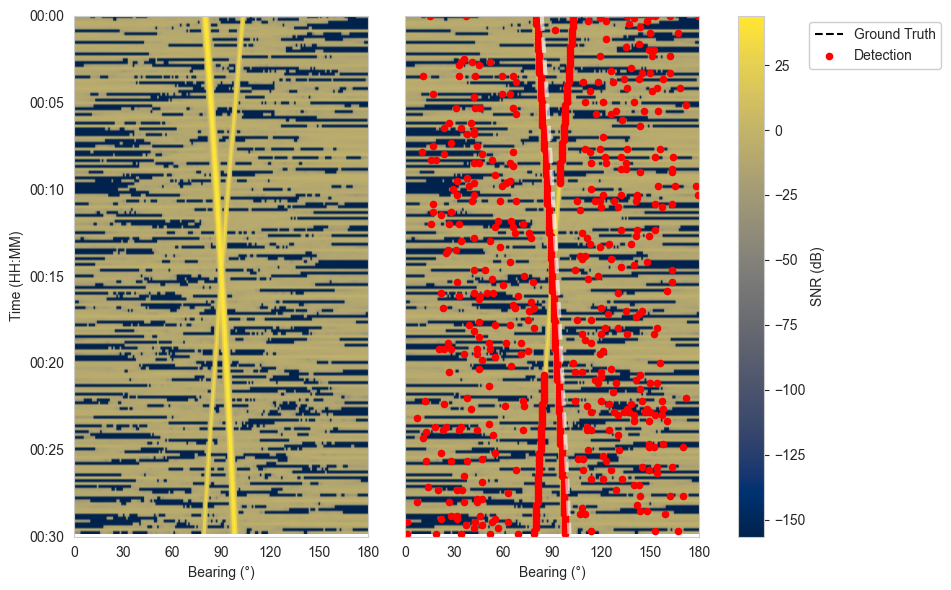

In [17]:
import matplotlib.pyplot as plt

from nereus.stonesoup.plotter import BearingsPlotter

detections_for_plotter = [detection_set for _, detection_set in all_detections]

timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"] \
        for i in range(SIM_PARAMS["num_steps"])
]

# Create the figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True, tight_layout=True)

# Instantiate the plotter
style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide)

# --- Left Plot: Raw SNR ---
plotter.plot_snr(
    snr_array=snr_map,
    timesteps=timesteps,
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False
)

# --- Right Plot: SNR with Detections & Truth ---
_, im = plotter.plot_snr(
    snr_array=snr_map,
    timesteps=timesteps,
    all_detections=detections_for_plotter,
    truths=[bearing_ground_truth],
    ax=axs[1],
    add_colorbar=False # We will add the colorbar manually below
)
axs[1].set_ylabel("") # Remove the duplicate y-axis label

# --- Add a single, shared colorbar ---
fig.colorbar(im, ax=axs.tolist(), label='SNR (dB)')

plt.show()